# Does a bad monsoon push up food prices?

Tests whether a weak monsoon raises food inflation, how many months it takes, and which foods react.

Data: MoSPI monthly CPI (2012 base for 2012 to 2025, 2024 base for 2026) and the Wholesale Price Index for food articles from the Office of the Economic Adviser (1953 to 2025). Rainfall from rainfall_record.ipynb.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

RAW = "data/raw/"
CLEAN = "data/clean/"

rain = pd.read_csv(CLEAN + "monsoon_rainfall_1871_2026.csv").set_index("year")

## Monthly CPI, 2012 to 2025

All-India combined (rural + urban) year-on-year inflation from the 2012 base series. The file has MoSPI's back and current versions for some months, so I keep the current one.

In [3]:
cpi = pd.read_csv(RAW + "mospi_cpi_2012_base_all_india.csv")
cpi = cpi[cpi["sector"] == "Combined"].dropna(subset=["inflation"])
cpi["date"] = pd.to_datetime(cpi["year"].astype(str) + "-" + cpi["month"], format="%Y-%B")

names = {
    "General-Overall": "headline",
    "Consumer Food Price-Overall": "food",
    "Cereals and Products": "cereals",
    "Pulses and Products": "pulses",
    "Vegetables": "vegetables",
}
cpi = cpi[cpi["subgroup"].isin(names)].drop_duplicates(["date", "subgroup"], keep="last")
monthly = cpi.pivot(index="date", columns="subgroup", values="inflation").rename(columns=names)
monthly = monthly[list(names.values())]
print(monthly.index.min().date(), "to", monthly.index.max().date())
monthly.tail(3)

2012-01-01 to 2025-12-01


subgroup,headline,food,cereals,pulses,vegetables
date,,,,,
2025-10-01,0.25,-5.02,0.92,-16.15,-27.57
2025-11-01,0.71,-3.91,0.10,-15.82,-22.24
2025-12-01,1.33,-2.71,-0.35,-15.09,-18.47


## How prices move after the monsoon

For each monsoon from 2012 to 2025, I take the change in inflation from June (when the monsoon starts) to each month after it, and regress that change on the monsoon's departure from normal. Doing this for 0 to 15 months gives the timing of the effect.

The results are shown as the effect of a monsoon 10% below normal. Only 11 to 14 monsoons are in this window, so the bands are wide.

In [4]:
def response(series, horizons=range(16)):
    rows = []
    for h in horizons:
        pairs = []
        for year in range(2012, 2026):
            start = pd.Timestamp(f"{year}-06-01")
            end = start + pd.DateOffset(months=h)
            if start in series.index and end in series.index:
                change = series[end] - series[start]
                if pd.notna(change):
                    pairs.append({"change": change, "departure": rain.loc[year, "departure"]})
        data = pd.DataFrame(pairs)
        m = smf.ols("change ~ departure", data=data).fit(cov_type="HC1")
        rows.append({
            "months_after_june": h,
            "effect_of_10pct_deficit": -10 * m.params["departure"],
            "se": 10 * m.bse["departure"],
            "monsoons": len(data),
        })
    return pd.DataFrame(rows).set_index("months_after_june")

responses = {col: response(monthly[col]) for col in ["food", "vegetables", "pulses", "cereals", "headline"]}
pd.DataFrame({col: r["effect_of_10pct_deficit"] for col, r in responses.items()}).round(2).iloc[[3, 6, 9, 12, 15]]

,food,vegetables,pulses,cereals,headline
months_after_june,,,,,
3,-0.86,-5.75,3.28,0.03,-0.61
6,-0.55,-2.89,5.86,-0.19,-0.58
9,0.59,8.15,6.16,-1.31,-0.41
12,1.67,12.72,8.19,-0.94,-0.08
15,1.15,9.16,7.59,-0.32,-0.28


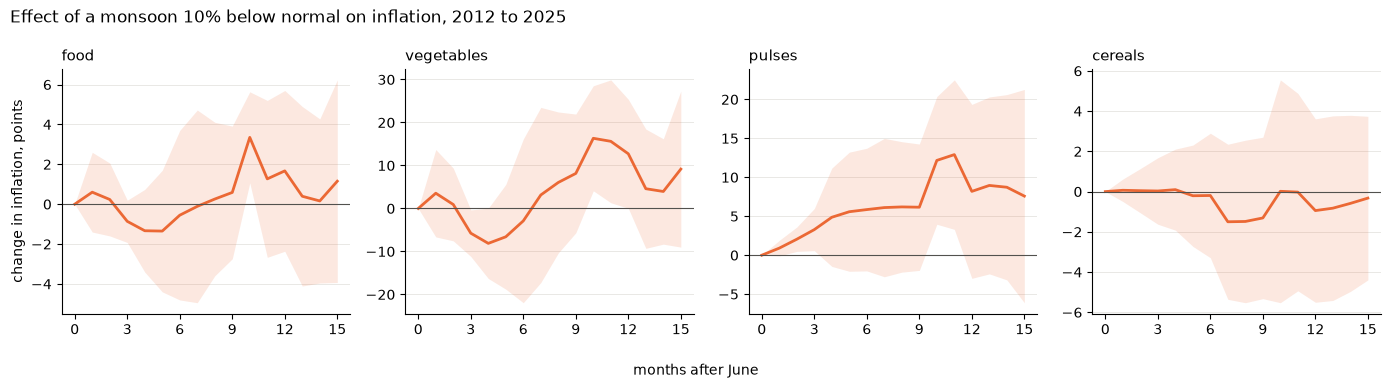

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8), sharex=True)
for ax, col in zip(axes, ["food", "vegetables", "pulses", "cereals"]):
    r = responses[col]
    ax.plot(r.index, r["effect_of_10pct_deficit"], color="#eb6834", linewidth=2)
    ax.fill_between(r.index, r["effect_of_10pct_deficit"] - 1.96 * r["se"],
                    r["effect_of_10pct_deficit"] + 1.96 * r["se"], color="#eb6834", alpha=0.15, linewidth=0)
    ax.axhline(0, color="#52514e", linewidth=0.8)
    ax.set_title(col, loc="left", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e5e4e0", linewidth=0.6)
    ax.set_axisbelow(True)
    ax.set_xticks([0, 3, 6, 9, 12, 15])
axes[0].set_ylabel("change in inflation, points")
fig.supxlabel("months after June", fontsize=10)
fig.suptitle("Effect of a monsoon 10% below normal on inflation, 2012 to 2025", x=0.01, ha="left")
plt.tight_layout()
plt.show()

## Long run: food prices since 1953

Monthly CPI only covers about 13 monsoons, so for the long run I use the Wholesale Price Index for food articles from the Office of the Economic Adviser (DPIIT). It has eight base years since 1952-53. I work out financial-year averages in each series and join the growth rates, taking each base year's average as 100.

In [6]:
def fy_start(date):
    return date.year if date.month >= 4 else date.year - 1

def find_row(table, text, cols):
    mask = False
    for c in cols:
        mask = mask | table[c].astype(str).str.lower().str.contains(text)
    return table[mask].iloc[0]

def old_monthly(filename, header_row):
    x = pd.read_excel(RAW + filename, header=None)
    dates = pd.to_datetime(x.iloc[header_row, 4:], errors="coerce")
    ok = dates.notna().values
    out = {}
    for name, text in [("food", "food articles"), ("all", "all commodities")]:
        row = find_row(x, text, [0, 1])
        values = pd.to_numeric(row.iloc[4:], errors="coerce")[ok]
        out[name] = pd.Series(values.values, index=dates[ok])
    return pd.DataFrame(out)

def monthly_1981(filename):
    x = pd.read_excel(RAW + filename)
    cols = [c for c in x.columns if str(c).upper().startswith(("INDEX", "INDX"))]
    def to_date(c):
        digits = "".join(ch for ch in str(c) if ch.isdigit())
        month, year = int(digits[:2]), int(digits[2:])
        return pd.Timestamp(year=year + 1900 if year < 100 else year, month=month, day=1)
    out = {}
    for name, text in [("food", "food articles"), ("all", "all commodities")]:
        row = find_row(x, text, ["COMM_NAME"])
        out[name] = pd.Series(pd.to_numeric(row[cols]).values, index=[to_date(c) for c in cols])
    return pd.DataFrame(out)

def fy_average(monthly_index):
    m = monthly_index.copy()
    m["fy"] = [fy_start(d) for d in m.index]
    groups = m.groupby("fy")
    return groups.mean()[groups.size() == 12]

def fy_file(filename):
    x = pd.read_excel(RAW + filename)
    name_col = [c for c in x.columns if "name" in str(c).lower()][0]
    year_cols = [c for c in x.columns if sum(ch.isdigit() for ch in str(c)) >= 4]
    out = {}
    for name, text in [("food", "food articles"), ("all", "all commodities")]:
        row = find_row(x, text, [name_col])
        years = [int("".join(ch for ch in str(c) if ch.isdigit())[:4]) for c in year_cols]
        out[name] = pd.Series(pd.to_numeric(row[year_cols]).values, index=years)
    return pd.DataFrame(out)

wpi = {
    1952: fy_average(old_monthly("oea_wpi_1952_53_base.xls", 2)),
    1961: fy_average(old_monthly("oea_wpi_1961_62_base.xls", 2)),
    1970: fy_average(old_monthly("oea_wpi_1970_71_base.xls", 1)),
    1981: fy_average(pd.concat([monthly_1981("oea_wpi_1981_82_base_monthly_1982_1991.xls"),
                                monthly_1981("oea_wpi_1981_82_base_monthly_1992_2000.xls")])),
    1993: fy_file("oea_wpi_1993_94_base_fy.xls"),
    2004: fy_file("oea_wpi_2004_05_base_fy.xls"),
    2011: fy_file("oea_wpi_2011_12_base_fy.xls"),
    2022: fy_file("oea_wpi_2022_23_base_fy.xlsx"),
}
for base, table in wpi.items():
    table.loc[base] = 100.0
    wpi[base] = table.sort_index()

# for each year use the newest series that has both that year and the year before
rows = []
for year in range(1953, 2026):
    for base in sorted(wpi, reverse=True):
        t = wpi[base]
        if base < year and year in t.index and year - 1 in t.index:
            growth = (t.loc[year] / t.loc[year - 1] - 1) * 100
            rows.append({"fy_start": year, "base": base,
                         "food_inflation": growth["food"], "all_inflation": growth["all"]})
            break
wpi_growth = pd.DataFrame(rows).set_index("fy_start")
print(len(wpi_growth), "years,", wpi_growth.index[0], "to", wpi_growth.index[-1])
wpi_growth.round(1).tail()

73 years, 1953 to 2025


,base,food_inflation,all_inflation
fy_start,,,
2021,2011,4.1,13.0
2022,2011,7.3,9.4
2023,2022,8.9,-0.7
2024,2022,7.5,1.7
2025,2022,-3.7,0.4


## Do deficient monsoons raise food inflation?

The monsoon of a year falls in that financial year, but most of the price effect should show up in the next one, after the kharif harvest. So I test both. Earlier tests in this study found the effect isn't a straight line, so I use a dummy for deficient years (below 90% of normal) and control for last year's food inflation and the oil shock years (1973, 1974, 1979, 1980).

In [7]:
annual = wpi_growth.join(rain[["departure", "category"]])
annual["deficient"] = (annual["category"] == "deficient").astype(int)
annual["food_next_year"] = annual["food_inflation"].shift(-1)
annual["food_last_year"] = annual["food_inflation"].shift(1)
annual["oil_shock"] = annual.index.isin([1973, 1974, 1979, 1980]).astype(int)

def fit(formula, data):
    return smf.ols(formula, data=data.dropna()).fit(cov_type="HAC", cov_kwds={"maxlags": 1})

results = {
    "same year": fit("food_inflation ~ deficient + food_last_year + oil_shock",
                     annual[["food_inflation", "deficient", "food_last_year", "oil_shock"]]),
    "next year": fit("food_next_year ~ deficient + food_last_year + oil_shock",
                     annual[["food_next_year", "deficient", "food_last_year", "oil_shock"]]),
}
pd.DataFrame({
    name: {"extra food inflation after a deficient monsoon (points)": m.params["deficient"],
           "p-value": m.pvalues["deficient"], "years": int(m.nobs)}
    for name, m in results.items()
}).round(3)

,same year,next year
extra food inflation after a deficient monsoon (points),1.522,4.646
p-value,0.330,0.050
years,72.000,71.000


In [8]:
deficient_years = annual[annual["deficient"] == 1][["departure", "food_inflation", "food_next_year"]]
deficient_years.round(1)

,departure,food_inflation,food_next_year
fy_start,,,
1965,-14.8,6.9,18.3
1966,-11.1,18.3,21.4
1972,-21.6,10.1,22.7
1979,-15.0,8.2,11.4
1982,-11.6,11.1,13.9
1986,-10.7,10.2,9.0
1987,-16.2,9.0,9.9
2002,-22.3,1.8,1.3
2004,-10.9,2.6,5.4


## 2026 so far

The 2026 monsoon was 12.6% below normal. Inflation from the new 2024 base series, January to August 2026.

In [9]:
new = pd.read_csv(RAW + "mospi_cpi_2024_base_all_india.csv")
new = new[(new["sector"] == "Combined") & new["group"].isna()
          & new["division"].isin(["CPI (General)", "Food and beverages"])].copy()
new["date"] = pd.to_datetime(new["year"].astype(str) + "-" + new["month"], format="%Y-%B")
latest = new.pivot(index="date", columns="division", values="inflation").dropna()
latest.columns = ["headline", "food and beverages"]
latest

,headline,food and beverages
date,,
2026-01-01,2.74,2.11
2026-02-01,3.21,3.35
2026-03-01,3.40,3.71
2026-04-01,3.48,4.01
2026-05-01,3.93,4.55
2026-06-01,4.38,5.05
2026-07-01,4.45,5.24
2026-08-01,4.82,5.66


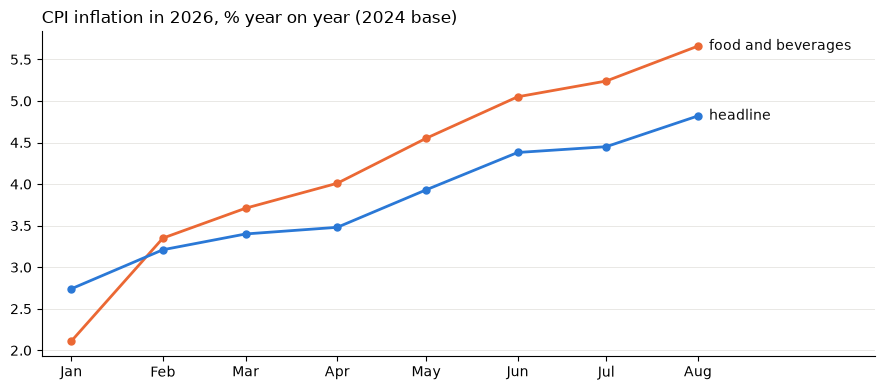

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
for col, color in [("food and beverages", "#eb6834"), ("headline", "#2a78d6")]:
    ax.plot(latest.index, latest[col], color=color, linewidth=2, marker="o", markersize=5)
    ax.annotate(col, (latest.index[-1], latest[col].iloc[-1]), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=10, color="#0b0b0b")
ax.set_title("CPI inflation in 2026, % year on year (2024 base)", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e5e4e0", linewidth=0.6)
ax.set_axisbelow(True)
ax.set_xticks(latest.index)
ax.set_xticklabels(latest.index.strftime("%b"))
ax.set_xlim(latest.index[0] - pd.Timedelta(days=10), latest.index[-1] + pd.Timedelta(days=60))
plt.tight_layout()
plt.show()

## Saving the data

In [11]:
monthly.round(3).to_csv(CLEAN + "cpi_monthly_2012_2025.csv")
annual.round(3).to_csv(CLEAN + "food_wpi_and_monsoon_1953_2025.csv")